# Identification des milieux relayeurs les plus progressifs (passes + conduites)

Ce notebook:
1. Charge les données ouvertes StatsBomb via `statsbombpy`.
2. Détecte automatiquement la saison complète la plus récente (championnat domestique).
3. Identifie les milieux relayeurs à partir des minutes jouées par poste.
4. Mesure la progression de balle par **passe** et par **conduite**.
5. Classe les joueurs en total et en volume **par 90 minutes**.

In [1]:
%pip install -q statsbombpy pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import urllib3
import requests
from statsbombpy import sb
import statsbombpy.public as _sbpub

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Workaround SSL environnement entreprise
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
_orig_get = requests.get

def _patched_get(url, **kwargs):
    kwargs.setdefault("verify", False)
    return _orig_get(url, **kwargs)

_sbpub.req.get = _patched_get

print("Librairies chargées.")

Librairies chargées.


In [11]:
competitions = sb.competitions()

league_whitelist = {
    "Premier League", "La Liga", "Serie A", "1. Bundesliga", "Bundesliga",
    "Ligue 1", "Eredivisie", "Primeira Liga", "FA Women's Super League",
    "Women's Super League", "Liga F", "NWSL"
}

# Ne garder que les competitions masculines
gender_col = "competition_gender"
if gender_col in competitions.columns:
    cand = competitions[
        competitions["competition_name"].isin(league_whitelist)
        & competitions[gender_col].astype(str).str.lower().eq("male")
    ].copy()
else:
    cand = competitions[competitions["competition_name"].isin(league_whitelist)].copy()

rows = []
for _, r in cand.iterrows():
    cid = int(r["competition_id"])
    sid = int(r["season_id"])
    try:
        m = sb.matches(competition_id=cid, season_id=sid)
        if m.empty:
            continue
        m = m.copy()
        m["match_date"] = pd.to_datetime(m["match_date"])
        teams = set(m["home_team"]).union(set(m["away_team"]))
        rows.append({
            "competition_id": cid,
            "season_id": sid,
            "competition_name": r["competition_name"],
            "season_name": r["season_name"],
            "n_matches": len(m),
            "n_teams": len(teams),
            "season_end": m["match_date"].max(),
        })
    except Exception:
        continue

season_candidates = pd.DataFrame(rows).sort_values("season_end", ascending=False)
season_candidates

,competition_id,season_id,competition_name,season_name,n_matches,n_teams,season_end
0,9,281,1. Bundesliga,2023/2024,34,18,2024-05-18
20,7,235,Ligue 1,2022/2023,32,20,2023-06-03
21,7,108,Ligue 1,2021/2022,26,18,2022-05-21
2,11,90,La Liga,2020/2021,35,19,2021-05-16
3,11,42,La Liga,2019/2020,33,20,2020-07-19
4,11,4,La Liga,2018/2019,34,20,2019-05-19
5,11,1,La Liga,2017/2018,36,20,2018-05-20
6,11,2,La Liga,2016/2017,34,20,2017-05-21
23,2,27,Premier League,2015/2016,380,20,2016-05-17
7,11,27,La Liga,2015/2016,380,20,2016-05-15


In [12]:
# Critère de saison "complète" (heuristique)
full = season_candidates[(season_candidates["n_matches"] >= 100) & (season_candidates["n_teams"] >= 10)].copy()
if full.empty:
    full = season_candidates.copy()

selected = full.sort_values("season_end", ascending=False).iloc[0]
COMP_ID = int(selected["competition_id"])
SEASON_ID = int(selected["season_id"])

matches = sb.matches(competition_id=COMP_ID, season_id=SEASON_ID).copy()
matches["match_date"] = pd.to_datetime(matches["match_date"])
matches = matches.sort_values("match_date").reset_index(drop=True)

print("Saison sélectionnée:")
print(f"- Compétition: {selected['competition_name']}")
print(f"- Saison: {selected['season_name']}")
print(f"- Matchs: {len(matches)}")
print(f"- Période: {matches['match_date'].min().date()} -> {matches['match_date'].max().date()}")

Saison sélectionnée:
- Compétition: Premier League
- Saison: 2015/2016
- Matchs: 380
- Période: 2015-08-08 -> 2016-05-17


In [ ]:
relayeur_positions = {
    "Left Center Midfield",
    "Center Midfield",
    "Right Center Midfield",
}

minutes_by_player = defaultdict(float)
minutes_by_position = defaultdict(lambda: defaultdict(float))
team_by_player = {}

all_events = []

def to_minute(value):
    if value is None:
        return None
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return None
        if ":" in value:
            parts = value.split(":")
            if len(parts) == 2:
                m, s = parts
                return float(m) + float(s) / 60.0
            if len(parts) == 3:
                h, m, s = parts
                return float(h) * 60.0 + float(m) + float(s) / 60.0
        return float(value)
    return None

for _, mrow in matches.iterrows():
    mid = int(mrow["match_id"])

    # Events
    ev = sb.events(match_id=mid)
    ev["match_id"] = mid
    all_events.append(ev)

    # Lineups (pour minutes + postes)
    lineup_dict = sb.lineups(match_id=mid)
    for team_name, ldf in lineup_dict.items():
        for _, prow in ldf.iterrows():
            player = prow.get("player_name")
            if not isinstance(player, str):
                continue
            team_by_player[player] = team_name

            positions = prow.get("positions", [])
            if not isinstance(positions, list):
                continue

            for p in positions:
                p_name = p.get("position")
                p_from = p.get("from")
                p_to = p.get("to")

                start_min = to_minute(p_from)
                if start_min is None:
                    continue

                end_min = to_minute(p_to)
                if end_min is None:
                    end_min = 120.0

                mins = max(0.0, end_min - start_min)

                minutes_by_player[player] += mins
                if isinstance(p_name, str):
                    minutes_by_position[player][p_name] += mins

events = pd.concat(all_events, ignore_index=True)
print(f"Events charges: {len(events):,}")
print(f"Joueurs avec minutes: {len(minutes_by_player)}")

In [7]:
def get_xy(loc):
    if isinstance(loc, list) and len(loc) >= 2:
        return float(loc[0]), float(loc[1])
    return np.nan, np.nan

# Passes complétées
passes = events[events["type"] == "Pass"].copy()
passes = passes[passes["pass_outcome"].isna()].copy()
passes[["x", "y"]] = pd.DataFrame(passes["location"].apply(get_xy).tolist(), index=passes.index)
passes[["end_x", "end_y"]] = pd.DataFrame(passes["pass_end_location"].apply(get_xy).tolist(), index=passes.index)
passes["prog_pass_m"] = (passes["end_x"] - passes["x"]).clip(lower=0)

# Conduites
carries = events[events["type"] == "Carry"].copy()
carries[["x", "y"]] = pd.DataFrame(carries["location"].apply(get_xy).tolist(), index=carries.index)
carries[["end_x", "end_y"]] = pd.DataFrame(carries["carry_end_location"].apply(get_xy).tolist(), index=carries.index)
carries["prog_carry_m"] = (carries["end_x"] - carries["x"]).clip(lower=0)

# Option: ignorer micro-progressions
passes = passes[passes["prog_pass_m"] >= 3].copy()
carries = carries[carries["prog_carry_m"] >= 3].copy()

pass_agg = passes.groupby("player").agg(
    progressive_pass_m=("prog_pass_m", "sum"),
    progressive_passes=("prog_pass_m", "count"),
).reset_index()

carry_agg = carries.groupby("player").agg(
    progressive_carry_m=("prog_carry_m", "sum"),
    progressive_carries=("prog_carry_m", "count"),
).reset_index()

progress = pass_agg.merge(carry_agg, on="player", how="outer").fillna(0)
progress["progressive_total_m"] = progress["progressive_pass_m"] + progress["progressive_carry_m"]
progress.head()

,player,progressive_pass_m,progressive_passes,progressive_carry_m,progressive_carries,progressive_total_m
0,Adriana Nanclares Romero,9856.8,426.0,719.0,103.0,10575.8
1,Agustina Barroso Basualdo,6134.5,441.0,1846.3,204.0,7980.8
2,Aina Meya,133.3,14.0,24.5,4.0,157.8
3,Ainhoa Alguacil Amores,2578.3,213.0,1864.3,179.0,4442.6
4,Ainhoa Delgado,59.8,2.0,92.0,7.0,151.8


In [8]:
rows = []
for player, mins in minutes_by_player.items():
    if mins <= 0:
        continue
    pos_minutes = minutes_by_position[player]
    relay_mins = sum(pos_minutes.get(p, 0.0) for p in relayeur_positions)
    relay_share = relay_mins / mins
    main_pos = max(pos_minutes, key=pos_minutes.get) if len(pos_minutes) else None

    rows.append({
        "player": player,
        "team": team_by_player.get(player, None),
        "minutes": mins,
        "relay_minutes": relay_mins,
        "relay_share": relay_share,
        "main_position": main_pos,
    })

player_profile = pd.DataFrame(rows)

# Définition opérationnelle du relayeur
relayeurs = player_profile[
    (player_profile["minutes"] >= 900) &
    (player_profile["relay_share"] >= 0.40)
].copy()

analysis = relayeurs.merge(progress, on="player", how="left").fillna(0)
analysis["progressive_pass_m_p90"] = analysis["progressive_pass_m"] / analysis["minutes"] * 90
analysis["progressive_carry_m_p90"] = analysis["progressive_carry_m"] / analysis["minutes"] * 90
analysis["progressive_total_m_p90"] = analysis["progressive_total_m"] / analysis["minutes"] * 90
analysis["progressive_actions_p90"] = (analysis["progressive_passes"] + analysis["progressive_carries"]) / analysis["minutes"] * 90

analysis = analysis.sort_values("progressive_total_m_p90", ascending=False).reset_index(drop=True)

print(f"Relayeurs détectés: {len(analysis)}")
analysis.head(20)[[
    "player", "team", "minutes", "main_position",
    "progressive_pass_m_p90", "progressive_carry_m_p90", "progressive_total_m_p90", "progressive_actions_p90"
]]

Relayeurs détectés: 17


,player,team,minutes,main_position,progressive_pass_m_p90,progressive_carry_m_p90,progressive_total_m_p90,progressive_actions_p90
0,Aitana Bonmati Conca,Barcelona WFC,2053.883333,Right Center Midfield,219.053338,107.971079,327.024417,29.753394
1,Paula Fernández Jiménez,Levante UD Femenino,2761.650000,Left Defensive Midfield,216.897507,99.234153,316.131660,27.342350
2,Angela Sosa Martín,Levante UD Femenino,2152.983333,Right Center Midfield,194.586272,115.441674,310.027946,25.583106
3,Fiamma Iannuzzi,Valencia CF,2698.416667,Left Center Midfield,178.741484,100.235447,278.976931,25.048022
4,Alexia Putellas Segura,Barcelona WFC,1467.016667,Left Center Midfield,198.132718,80.765954,278.898672,28.772679
5,Victoria López,Barcelona WFC,1648.400000,Right Center Midfield,158.908639,102.743266,261.651905,26.862412
6,Andreia de Jesus Jacinto,Real Sociedad de Fútbol,3187.483333,Left Center Midfield,185.105909,72.268613,257.374522,22.334234
7,Klára Cahynová,Sevilla FC,2611.216667,Right Center Midfield,164.633600,64.614707,229.248307,20.369815
8,Gema Gili Giner,Sevilla FC,1909.300000,Left Center Midfield,159.584665,42.970722,202.555387,16.451055
9,Ainhoa Alguacil Amores,Valencia CF,2004.300000,Right Center Midfield,115.774585,83.713516,199.488101,17.602155


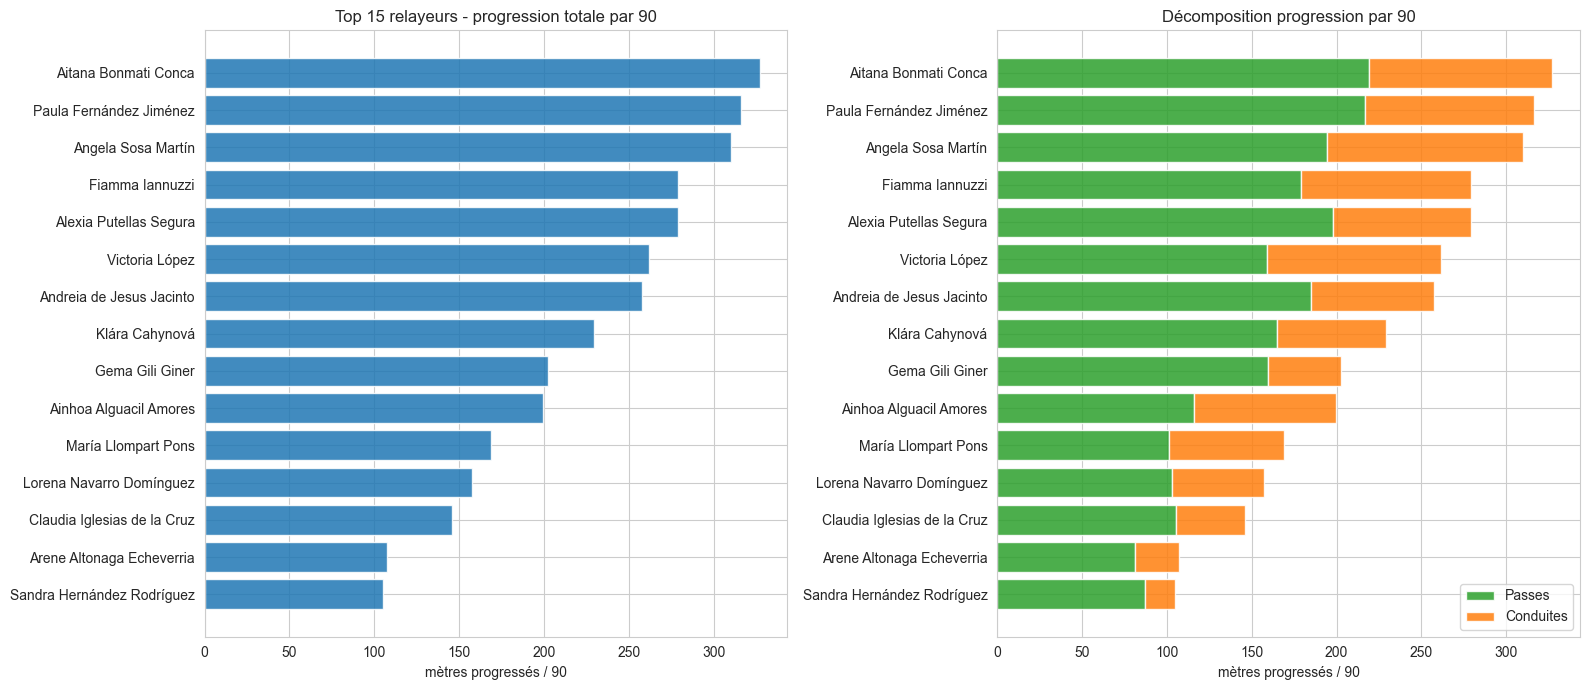

In [9]:
top_n = 15
plot_df = analysis.head(top_n).sort_values("progressive_total_m_p90", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")

# Graphe 1: progression totale
axes[0].barh(plot_df["player"], plot_df["progressive_total_m_p90"], color="#1f77b4", alpha=0.85)
axes[0].set_title(f"Top {top_n} relayeurs - progression totale par 90")
axes[0].set_xlabel("mètres progressés / 90")

# Graphe 2: split passe vs conduite
axes[1].barh(plot_df["player"], plot_df["progressive_pass_m_p90"], color="#2ca02c", alpha=0.85, label="Passes")
axes[1].barh(plot_df["player"], plot_df["progressive_carry_m_p90"], left=plot_df["progressive_pass_m_p90"],
             color="#ff7f0e", alpha=0.85, label="Conduites")
axes[1].set_title("Décomposition progression par 90")
axes[1].set_xlabel("mètres progressés / 90")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Tableau final exportable
final_cols = [
    "player", "team", "minutes", "main_position", "relay_share",
    "progressive_pass_m", "progressive_carry_m", "progressive_total_m",
    "progressive_pass_m_p90", "progressive_carry_m_p90", "progressive_total_m_p90", "progressive_actions_p90"
]

final_table = analysis[final_cols].copy()
final_table = final_table.sort_values("progressive_total_m_p90", ascending=False)

for c in [
    "relay_share", "progressive_pass_m_p90", "progressive_carry_m_p90",
    "progressive_total_m_p90", "progressive_actions_p90"
]:
    final_table[c] = final_table[c].round(2)

final_table.head(30)

,player,team,minutes,main_position,relay_share,progressive_pass_m,progressive_carry_m,progressive_total_m,progressive_pass_m_p90,progressive_carry_m_p90,progressive_total_m_p90,progressive_actions_p90
0,Aitana Bonmati Conca,Barcelona WFC,2053.883333,Right Center Midfield,0.92,4999.0,2464.0,7463.0,219.05,107.97,327.02,29.75
1,Paula Fernández Jiménez,Levante UD Femenino,2761.650000,Left Defensive Midfield,0.42,6655.5,3045.0,9700.5,216.90,99.23,316.13,27.34
2,Angela Sosa Martín,Levante UD Femenino,2152.983333,Right Center Midfield,0.63,4654.9,2761.6,7416.5,194.59,115.44,310.03,25.58
3,Fiamma Iannuzzi,Valencia CF,2698.416667,Left Center Midfield,0.62,5359.1,3005.3,8364.4,178.74,100.24,278.98,25.05
4,Alexia Putellas Segura,Barcelona WFC,1467.016667,Left Center Midfield,0.70,3229.6,1316.5,4546.1,198.13,80.77,278.90,28.77
5,Victoria López,Barcelona WFC,1648.400000,Right Center Midfield,0.68,2910.5,1881.8,4792.3,158.91,102.74,261.65,26.86
6,Andreia de Jesus Jacinto,Real Sociedad de Fútbol,3187.483333,Left Center Midfield,0.57,6555.8,2559.5,9115.3,185.11,72.27,257.37,22.33
7,Klára Cahynová,Sevilla FC,2611.216667,Right Center Midfield,0.45,4776.6,1874.7,6651.3,164.63,64.61,229.25,20.37
8,Gema Gili Giner,Sevilla FC,1909.300000,Left Center Midfield,0.52,3385.5,911.6,4297.1,159.58,42.97,202.56,16.45
9,Ainhoa Alguacil Amores,Valencia CF,2004.300000,Right Center Midfield,0.65,2578.3,1864.3,4442.6,115.77,83.71,199.49,17.60
